# Exploratory Data Analysis (EDA) of The Insurance Dataset

### 1) Import Libraries

In [1]:
# Import libraries and modules

# ---------- path setup ----------
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent.parent
sys.path.insert(0, str(PROJECT_ROOT / "Notebooks"))
DATA_DIR = PROJECT_ROOT / "Data/insurance_dataset"


#----- Tools, visualizers -----
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from utils import *


### 2) Load Data and Inspect

In [2]:
#---------------
# Load dataset
#---------------
insurance_data = pd.read_csv(DATA_DIR / "insurance.csv")
insurance_data.head(20)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [3]:
#-----------------
# Inspect & Info
#-----------------

# Get info and statistics
print(insurance_data.info(), end="\n\n")
print(insurance_data.describe().T, end="\n\n")
print(20*"--")
# Check shape of the dataset
print(f"Shape of the dataset: {insurance_data.shape}", end="\n\n")
# Count missing values
print(f"Counts of missing values:\n{insurance_data.isna().sum()}", end="\n\n")
# Count duplicated values
print(f"Counts of duplicated values: {insurance_data.duplicated().sum()}", end="\n\n")
# Check uniqueness of values
# Count unique values in each col
print(insurance_data.nunique(), end="\n\n")
# Get columns & their unique values
unique_values = {col: insurance_data[col].unique().tolist()
                  for col, value in zip(insurance_data.columns.tolist(), insurance_data.nunique()) if value <= 7}
unique_values

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None

           count          mean           std        min         25%       50%  \
age       1338.0     39.207025     14.049960    18.0000    27.00000    39.000   
bmi       1338.0     30.663397      6.098187    15.9600    26.29625    30.400   
children  1338.0      1.094918      1.205493     0.0000     0.00000     1.000   
charges   1338.0  13270.422265  12110.011237  1121.8739  4740.28715  9382.033   

                   75%          max  
age          51.000000     64.00000  
bmi    

{'sex': ['female', 'male'],
 'children': [0, 1, 3, 2, 5, 4],
 'smoker': ['yes', 'no'],
 'region': ['southwest', 'southeast', 'northwest', 'northeast']}

### 3) Check Distribution

#### - Target

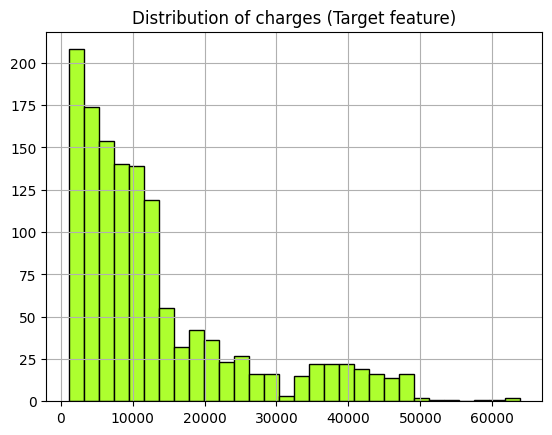

In [4]:
# Visualize features distribution
insurance_data['charges'].hist(
    #figsize=(12, 10), 
    color='greenyellow',
    edgecolor='black',
    bins=30
)
plt.title("Distribution of charges (Target feature)")
plt.show()

> The distribution of charges is strongly right-skewed which suggests that a log transform may help enormously.

In [5]:
target_log = np.log1p(insurance_data['charges']) # Apply log transformation

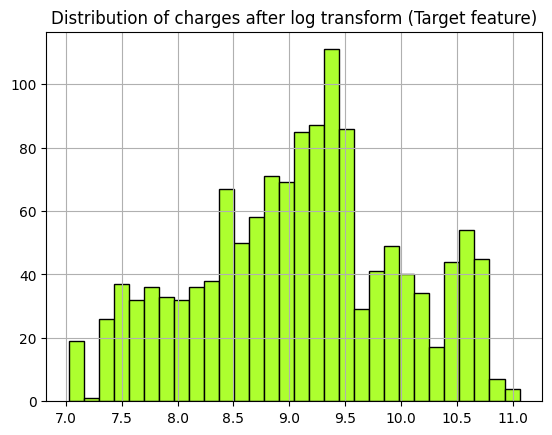

In [6]:
# Visualize features distribution
target_log.hist(
    #figsize=(12, 10), 
    color='greenyellow',
    edgecolor='black',
    bins=30
)
plt.title("Distribution of charges after log transform (Target feature)")
plt.show()

#### - Numeric features

In [32]:
continuous_num_feat = ['bmi', 'age']

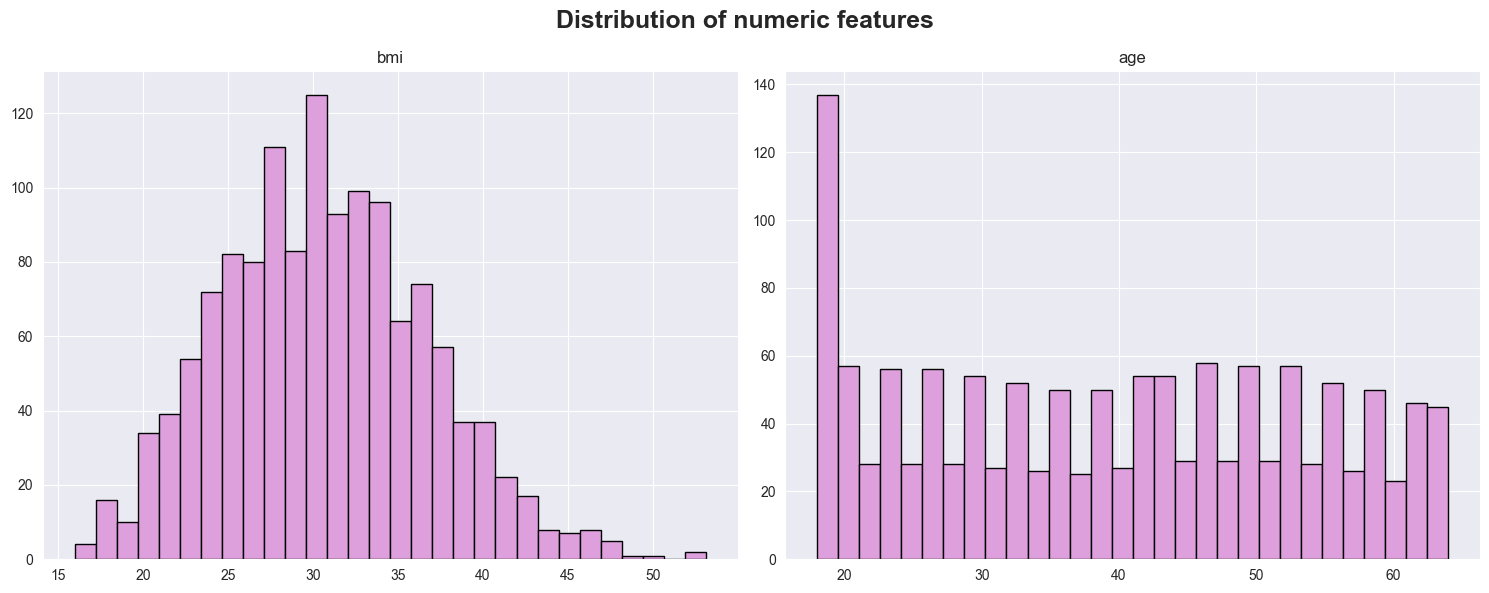

In [33]:
# Visualize features distribution
insurance_data[continuous_num_feat].hist(
    figsize=(15, 6), 
    color='plum',
    edgecolor='black',
    bins=30
)
plt.suptitle("Distribution of numeric features", fontsize=18, weight='bold')
plt.tight_layout()
plt.show()

#### - Categorical features

In [9]:
# Get object categorical features 
cat_feat_cols = list(unique_values.keys())
# Print each column's value counts
for f in cat_feat_cols:
    print(insurance_data[f].value_counts())
    print(insurance_data[f].value_counts(normalize=True))
    print(20*"---")

sex
male      676
female    662
Name: count, dtype: int64
sex
male      0.505232
female    0.494768
Name: proportion, dtype: float64
------------------------------------------------------------
children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64
children
0    0.428999
1    0.242152
2    0.179372
3    0.117339
4    0.018685
5    0.013453
Name: proportion, dtype: float64
------------------------------------------------------------
smoker
no     1064
yes     274
Name: count, dtype: int64
smoker
no     0.795217
yes    0.204783
Name: proportion, dtype: float64
------------------------------------------------------------
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
region
southeast    0.272048
southwest    0.242900
northwest    0.242900
northeast    0.242152
Name: proportion, dtype: float64
------------------------------------------------------------


In [10]:
cat_feats = insurance_data[cat_feat_cols]

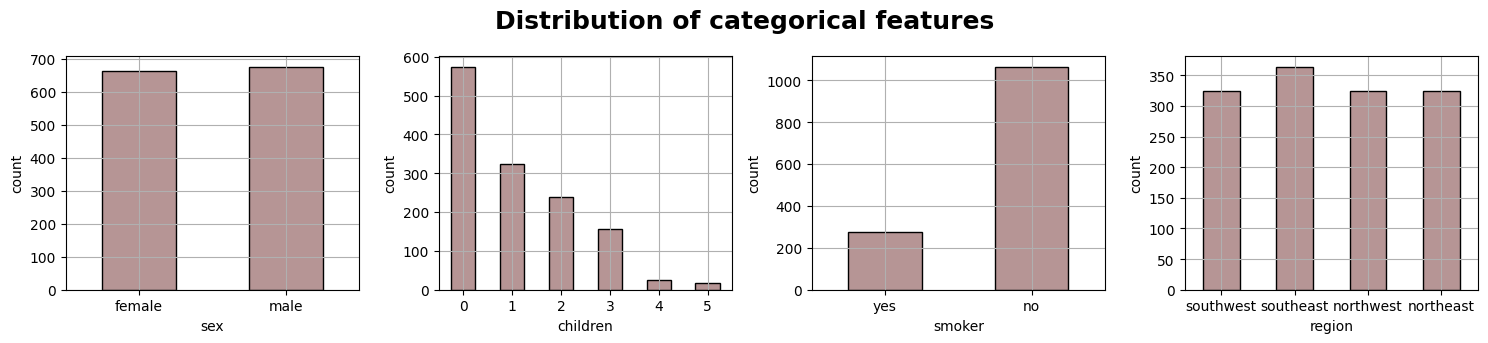

In [14]:
# Create figure and its size/shape
fig, axes = plt.subplots(2, 4, figsize=(15, 6))

# Flatten axes array for easy looping
axes = axes.flatten()

# Loop through the dataframe and get (index, column)
for i, col in enumerate(cat_feats):
    # Adjust the plot
    sns.countplot(x=col, data=cat_feats, ax=axes[i], width=0.5,
                   color='rosybrown', edgecolor='black')

    # Add grid
    axes[i].grid()

# If there are empty subplots, remove them
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribution of categorical features", fontsize=18, weight='bold')
plt.tight_layout()
plt.show()

### 4) Check Boxplots (Num features)

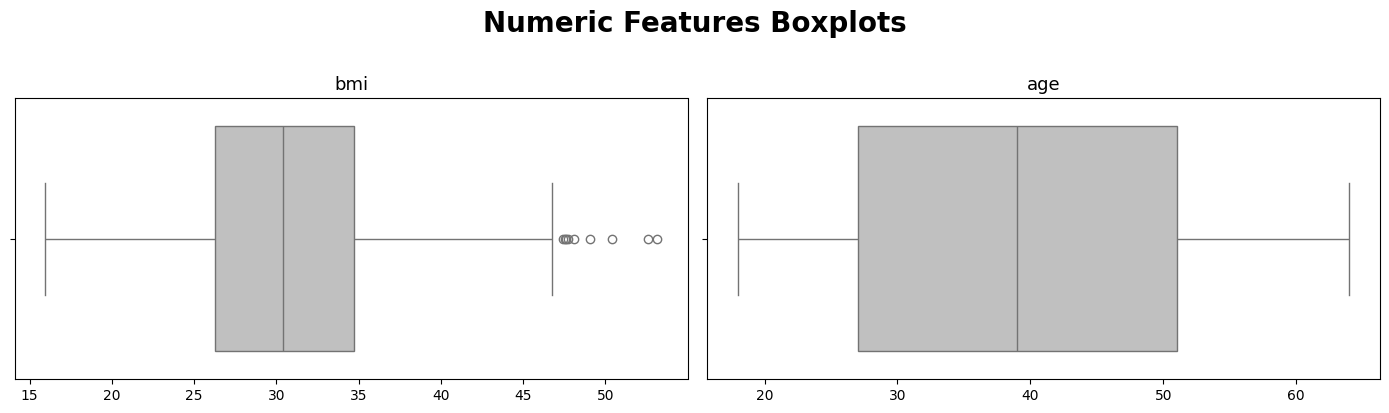

In [15]:
def boxplot(train, color="silver", title="Numeric Features Boxplots"):
    # Figure
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes = axes.flatten()
    # Visualize
    for i, col in enumerate(train):
        sns.boxplot(data=train, x=col, ax=axes[i], color=color)
        axes[i].set_title(col, fontsize=13)
        axes[i].set_xlabel("")  # Remove x-labels for clean look
    
    # If there are empty subplots, remove them
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(title, fontsize=20, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

boxplot(insurance_data[continuous_num_feat])


### 5) Check Pairplots (Num features)

In [16]:
x = round(2*(insurance_data['charges'].max() - insurance_data['charges'].min()) / 5)
x

25059

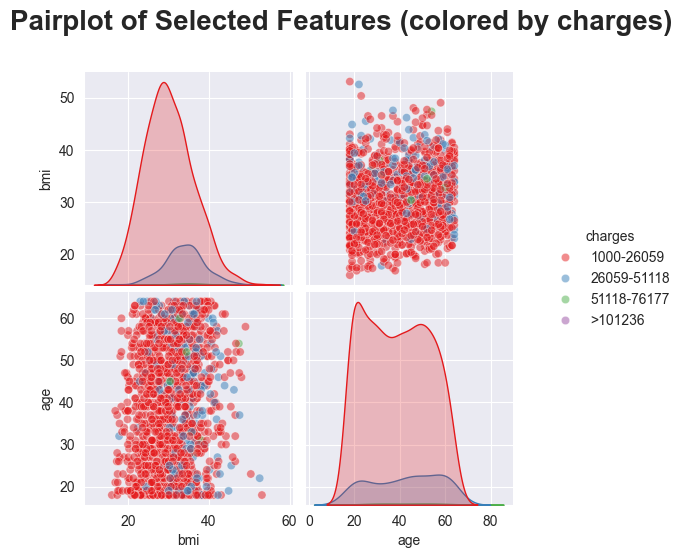

In [17]:
# Make a copy of external data
ins_data_copy = insurance_data.copy()
# Categorize `charges` into 6 categories
ins_data_copy['charges'] = pd.cut(ins_data_copy['charges'], bins=[1000, x+1000, 2*x+1000, 3*x+1000, 4*x+1000],
                            labels=[f'1000-{x+1000}', f'{x+1000}-{2*x+1000}', f'{2*x+1000}-{3*x+1000}', f'>{4*x+1000}'])

# Features + the target
selected = continuous_num_feat + ['charges']

# Visualize pairplots
sns.set_style("darkgrid")
sns.pairplot(
    ins_data_copy[selected],
    hue="charges",
    palette="Set1",
    plot_kws={'alpha': 0.5},
    diag_kind="kde"
)

plt.suptitle("Pairplot of Selected Features (colored by charges)",
              fontsize=20, fontweight="bold", y=1.1)
plt.show()


### 6) Check skewness and outliers of numerical features


**Threshold of skewness:**

- |skew| < 0.5 →  Almost symmetric → leave it as is

- 0.5 ≤ |skew| < 1 →  Moderate skew → consider transforming (if it matters for your model)

- |skew| ≥ 1 →  High skew → strongly consider transformation

In [18]:
skewness_detector(insurance_data[continuous_num_feat])

,Feature,Skewness,Skewness_Exceeding_Threshold
0,bmi,0.284047,False
1,age,0.055673,False


In [19]:
outlier_detector(insurance_data[continuous_num_feat])

,Feature,N_outliers,Outlier_pct
0,bmi,9,0.673
1,age,0,0.000


### 7) Check correlations of features and classes
- Numeric ↔ Numeric Correlations
- Categorical ↔ Categorical Correlations
- Categorical ↔ Numeric Correlations
- Feature ↔ Target Correlations
    - Continuous Numeric features ↔ Target
    - Categorical features ↔ Target

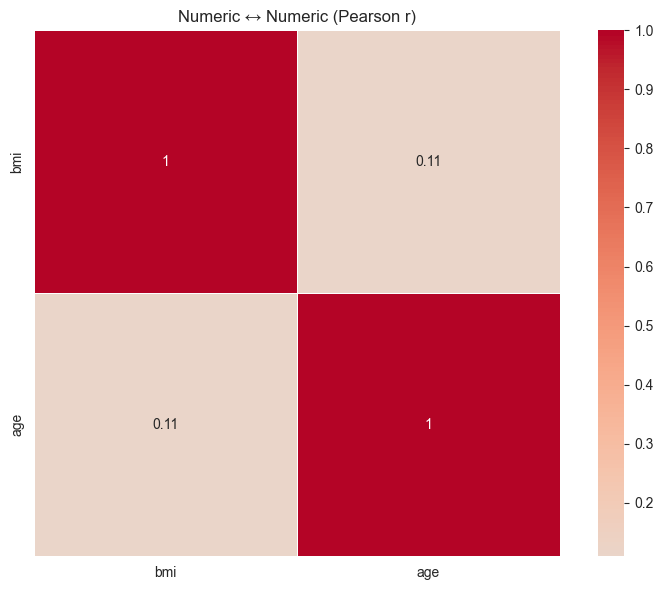

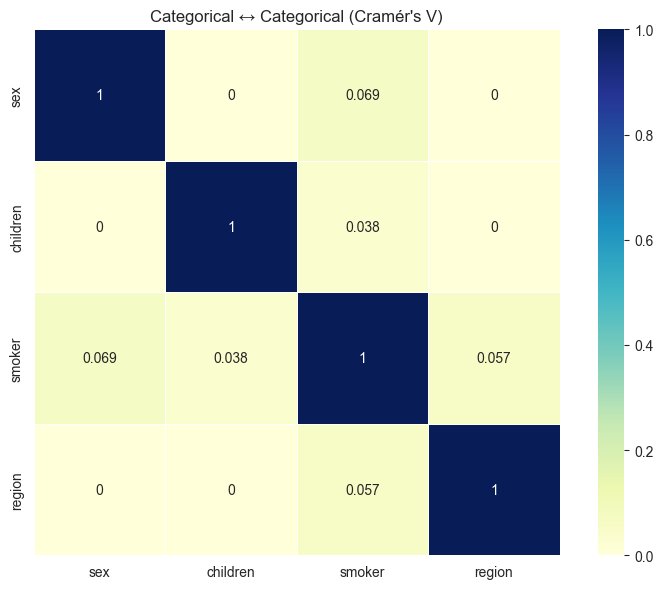

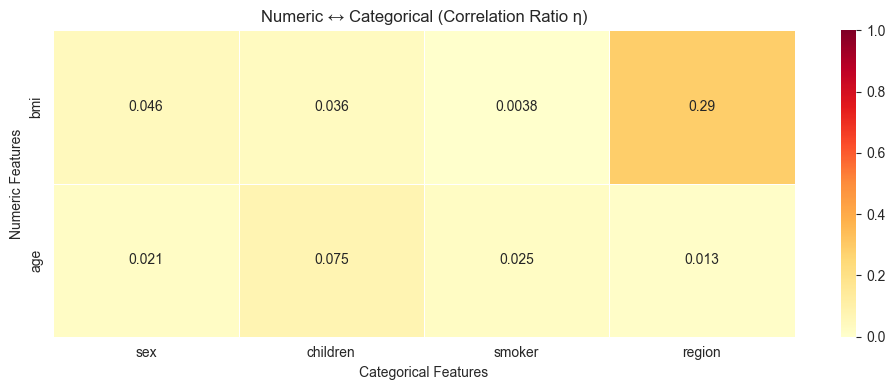

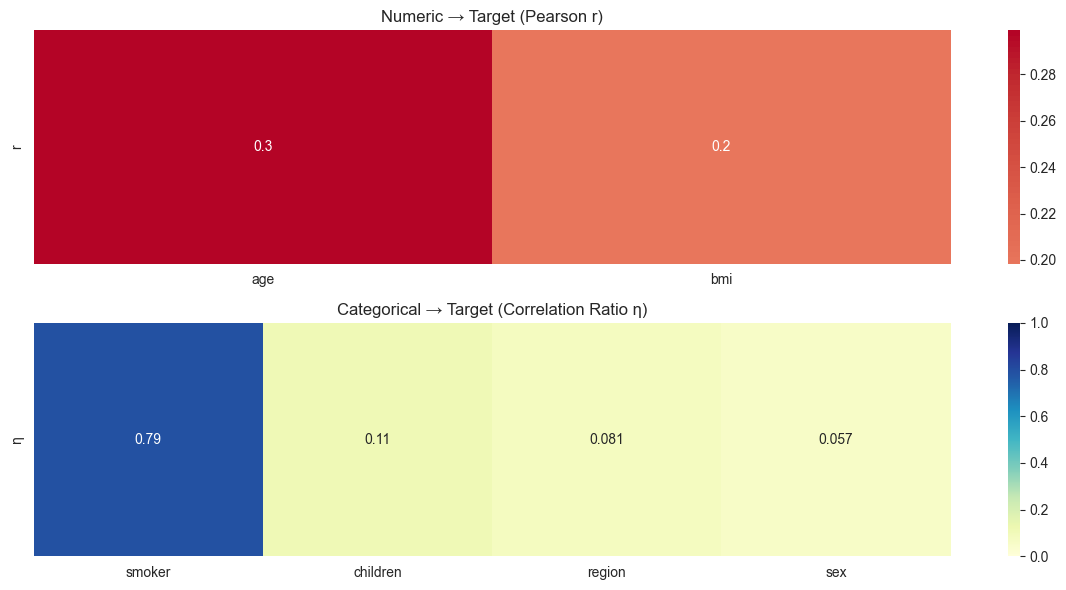

In [20]:
# Get columns name as lists

categorical_features = cat_feats.columns.tolist()

analyzer = CorrelationAnalyzer(
    data=insurance_data,
    target_type='numeric',
    num_cols=continuous_num_feat,
    cat_cols=categorical_features,
    target_col='charges'
)

analyzer.plot_all()
all_results = analyzer.get_correlation_results()

### 9) Analyze possible feature engineering scenarios
Correlation plots of features vs. the target are tested in this section.

In [21]:
from sklearn.preprocessing import label_binarize
insu_copy = insurance_data.copy()
insu_copy['smoker'] = label_binarize(insu_copy['smoker'], classes=['no', 'yes'])


In [23]:
# Some feature eng
insu_copy['bmi_smoker'] = insu_copy['bmi'] * insu_copy['smoker']
insu_copy['age_smoker'] = insu_copy['age'] * insu_copy['smoker']
insu_copy['bmi_age'] = insu_copy['age'] * insu_copy['bmi']

insu_copy['obesity'] = np.where(insu_copy['bmi'] >= 30, 1, 0)
insu_copy['severe_obesity'] = np.where(insu_copy['bmi'] >= 35, 1, 0)
insu_copy['high_risk'] = insu_copy['obesity'] * insu_copy['smoker']

In [24]:
insu_copy

,age,sex,bmi,children,smoker,region,charges,bmi_smoker,age_smoker,bmi_age,obesity,severe_obesity,high_risk
0,19,female,27.900,0,1,southwest,16884.92400,27.90,19,530.100,0,0,0
1,18,male,33.770,1,0,southeast,1725.55230,0.00,0,607.860,1,0,0
2,28,male,33.000,3,0,southeast,4449.46200,0.00,0,924.000,1,0,0
3,33,male,22.705,0,0,northwest,21984.47061,0.00,0,749.265,0,0,0
4,32,male,28.880,0,0,northwest,3866.85520,0.00,0,924.160,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,0,northwest,10600.54830,0.00,0,1548.500,1,0,0
1334,18,female,31.920,0,0,northeast,2205.98080,0.00,0,574.560,1,0,0
1335,18,female,36.850,0,0,southeast,1629.83350,0.00,0,663.300,1,1,0
1336,21,female,25.800,0,0,southwest,2007.94500,0.00,0,541.800,0,0,0


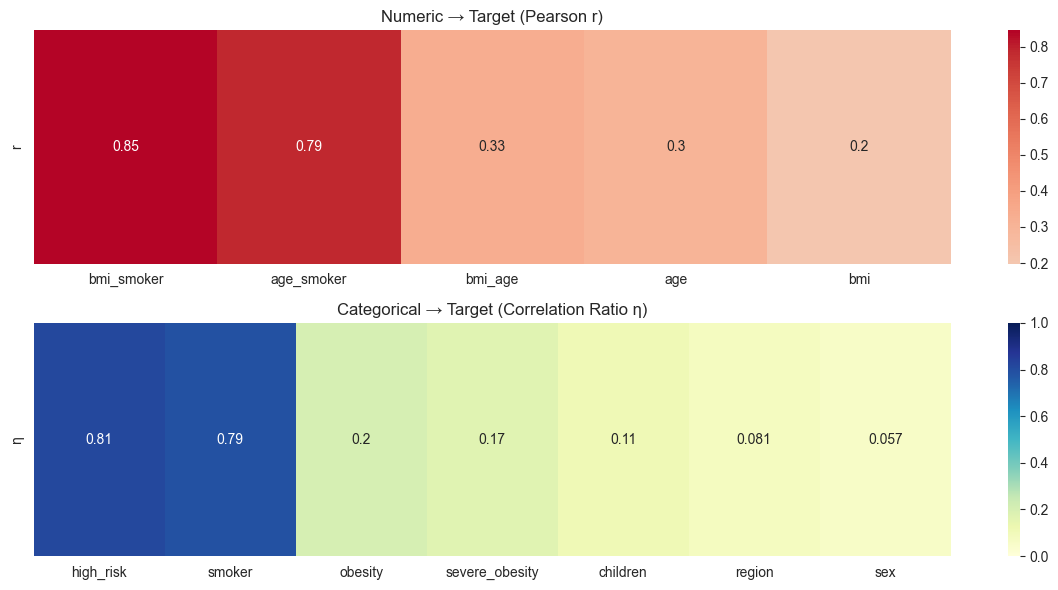

In [27]:
# Get columns name as lists

categorical_features = cat_feats.columns.tolist() + ['obesity', 'severe_obesity', 'high_risk']
continuous_num_feat_ = continuous_num_feat + ['bmi_smoker', 'age_smoker', 'bmi_age']

analyzer_fe = CorrelationAnalyzer(
    data=insu_copy,
    target_type='numeric',
    num_cols=continuous_num_feat_,
    cat_cols=categorical_features,
    target_col='charges'
)

analyzer_fe.plot_feature_numeric_target()
all_fe = analyzer_fe.get_correlation_results()

In [28]:
all_fe

{'num_num': None,
 'cat_cat': None,
 'num_cat': None,
 'num_target':    bmi_smoker  age_smoker   bmi_age       age       bmi
 r     0.84512    0.789253  0.334754  0.299008  0.198341,
 'cat_target':    high_risk    smoker   obesity  severe_obesity  children    region       sex
 η   0.814661  0.787251  0.199532        0.169194  0.110565  0.081449  0.057292}

### 10) Split the dataset into train and test sets

In [29]:
from sklearn.model_selection import train_test_split

# Keep 15% as final test set
train_set, test_set = train_test_split(insurance_data, test_size=0.15, random_state=42)

train_set.to_csv(DATA_DIR / "insurance_train_set.csv", index=False)
test_set.to_csv(DATA_DIR / "insurance_test_set.csv", index=False)

print(f"Train set: {len(train_set)}  |  Test set: {len(test_set)}")

Train set: 1137  |  Test set: 201
